# Two-Stage Routing Model Performance Analysis

        This notebook evaluates the saved two-stage car price prediction system:

        1. **Stage 1 Router:** classifies each vehicle as Everyday (`< $150k`) or Exotic (`>= $150k`).
        2. **Stage 2 Everyday Regressor:** predicts price for vehicles routed to the Everyday lane.
        3. **Stage 3 Exotic Regressor:** predicts price for vehicles routed to the Exotic lane.

        The goal is not only to report a global error score, but to understand where routing helps, where it fails, and which price bands need more modeling attention.


## Step 1: Environment Setup & Data Loading

        These cells install optional plotting/interpretability packages, import the project training split function, regenerate the exact deterministic test split, and load the three primary saved models. Reusing `load_and_split_data()` keeps the evaluation data aligned with training logic, including the ABSA join, `vehicle_age`, and high-value stratification.


In [1]:
!pip install matplotlib seaborn shap


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.3 MB 4.9 MB/s eta 0:00:02
   -------- ------------------------------- 2.1/9.3 MB 5.4 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.3 MB 5.6 MB/s eta 0:00:02
   ------------------- -------------------- 4.5/9.3 MB 5.4 MB/s eta 0:00:01
   ----------------------- ---------------- 5.5/9.3 MB 5.4 MB/s eta 0:00:01
   ----------------------------- ---------- 6.8/9.3 MB 5.4 MB/s eta 0:00:01
   --------------------------------- ------ 7.9/9.3 MB 5.3 MB/s eta 0:00:01
   -------------------------------------- - 8.9/9.3 MB 5.3 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 5.2 MB/s  0:00:01
Using cached seaborn-0.13.2-py3-none-any.whl (


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import sys
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "ML" / "Price_ML_Models.py").exists():
    if (PROJECT_ROOT / "Price_ML_Models.py").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent
    else:
        raise FileNotFoundError("Could not locate Price_ML_Models.py from the current working directory.")

ML_DIR = PROJECT_ROOT / "ML"
MODEL_DIR = PROJECT_ROOT / "MODELS_OUTPUT"
sys.path.insert(0, str(ML_DIR))

from Price_ML_Models import HIGH_VALUE_THRESHOLD, load_and_split_data

print(f"Project root: {PROJECT_ROOT}")
print(f"Model directory: {MODEL_DIR}")
print(f"High-value threshold: ${HIGH_VALUE_THRESHOLD:,.0f}")


Project root: C:\Users\danie\Code\Car-Price-Data-Visualization-Learning
Model directory: C:\Users\danie\Code\Car-Price-Data-Visualization-Learning\MODELS_OUTPUT
High-value threshold: $150,000


In [3]:
X_train, y_train, X_test, y_test = load_and_split_data()

classifier = joblib.load(MODEL_DIR / "Stage1_High_Value_Router.joblib")
everyday_regressor = joblib.load(MODEL_DIR / "Stage2_Everyday_LightGBM.joblib")
exotic_regressor = joblib.load(MODEL_DIR / "Stage3_Exotic_RandomForest.joblib")

print(f"X_test shape: {X_test.shape}")
print(f"Everyday test rows: {(y_test < HIGH_VALUE_THRESHOLD).sum():,}")
print(f"High-value test rows: {(y_test >= HIGH_VALUE_THRESHOLD).sum():,}")


Loading data from C:\Users\danie\Code\Car-Price-Data-Visualization-Learning\CAR_DATA_OUTPUT\CAR_DATA_CLEANED.db
Train size: 3,226,603 | Test size: 806,651
High-value train/test rates: 0.0075 / 0.0075
X_test shape: (806651, 90)
Everyday test rows: 800,634
High-value test rows: 6,017


## Step 2: Stage 1 Classifier Analysis

        The router is the most important control point in this architecture. Because high-value vehicles are rare, a high overall accuracy can hide bad routing behavior. The plots below focus on the minority class and on the mistakes that send rows to the wrong downstream regressor.


### Confusion Matrix

        The dataset is dominated by Everyday cars, so the confusion matrix must be read with special attention to the off-diagonal cells. False positives are Everyday cars routed to the Exotic model; these matter because the Exotic regressor was trained on a very different price distribution. If router precision is around 61%, those false-positive routes are a key source of stakeholder-visible pricing errors.


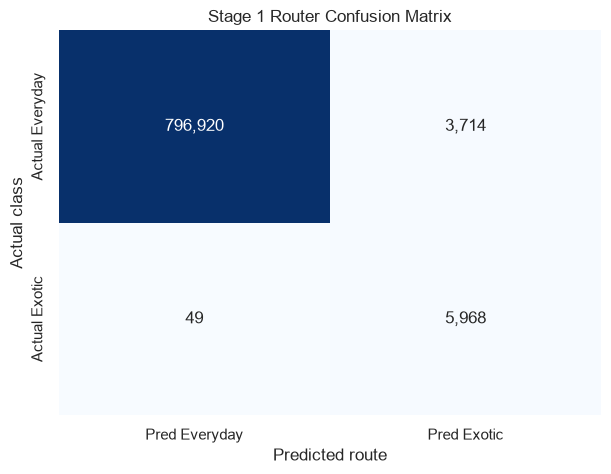

False positives (Everyday routed to Exotic): 3,714
False negatives (Exotic routed to Everyday): 49
Exotic precision: 0.6164
Exotic recall: 0.9919


In [4]:
y_route_true = (y_test >= HIGH_VALUE_THRESHOLD).astype(int)
y_route_pred = classifier.predict(X_test)
y_route_prob = classifier.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_route_true, y_route_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual Everyday", "Actual Exotic"],
    columns=["Pred Everyday", "Pred Exotic"],
)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt=",d", cmap="Blues", cbar=False)
plt.title("Stage 1 Router Confusion Matrix")
plt.ylabel("Actual class")
plt.xlabel("Predicted route")
plt.show()

tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp) if (tp + fp) else np.nan
recall = tp / (tp + fn) if (tp + fn) else np.nan
print(f"False positives (Everyday routed to Exotic): {fp:,}")
print(f"False negatives (Exotic routed to Everyday): {fn:,}")
print(f"Exotic precision: {precision:.4f}")
print(f"Exotic recall: {recall:.4f}")


### Precision-Recall Curve

        For a rare positive class, ROC curves can look deceptively strong because true negatives dominate the denominator. A precision-recall curve is more informative here: it shows the direct tradeoff between catching Exotic vehicles and avoiding unnecessary Exotic routes when only about 0.75% of rows are positive.


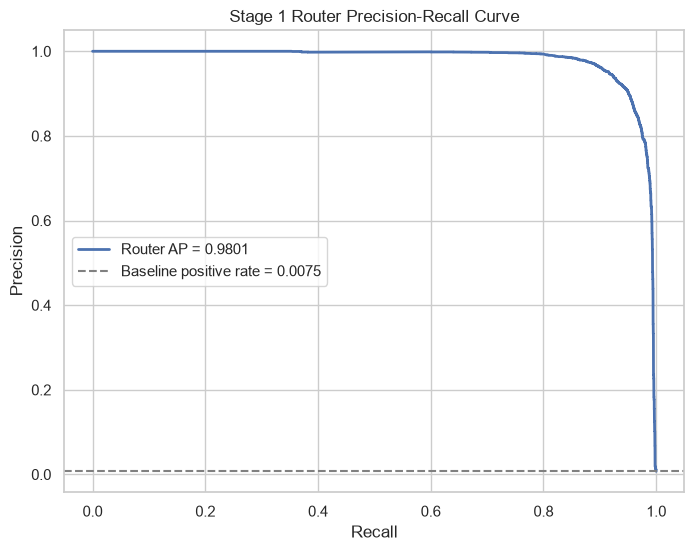

In [5]:
precision_values, recall_values, thresholds = precision_recall_curve(y_route_true, y_route_prob)
avg_precision = average_precision_score(y_route_true, y_route_prob)
positive_rate = y_route_true.mean()

plt.figure(figsize=(8, 6))
plt.plot(recall_values, precision_values, label=f"Router AP = {avg_precision:.4f}", linewidth=2)
plt.axhline(positive_rate, color="gray", linestyle="--", label=f"Baseline positive rate = {positive_rate:.4f}")
plt.title("Stage 1 Router Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()


### Elastic-Net Logistic Coefficients

        The soft-voting router includes a linear elastic-net logistic regression. Its largest absolute coefficients provide a compact explanation of what linearly pushes a vehicle toward the Exotic route. This is especially useful as a sanity check beside the more flexible LightGBM classifier.


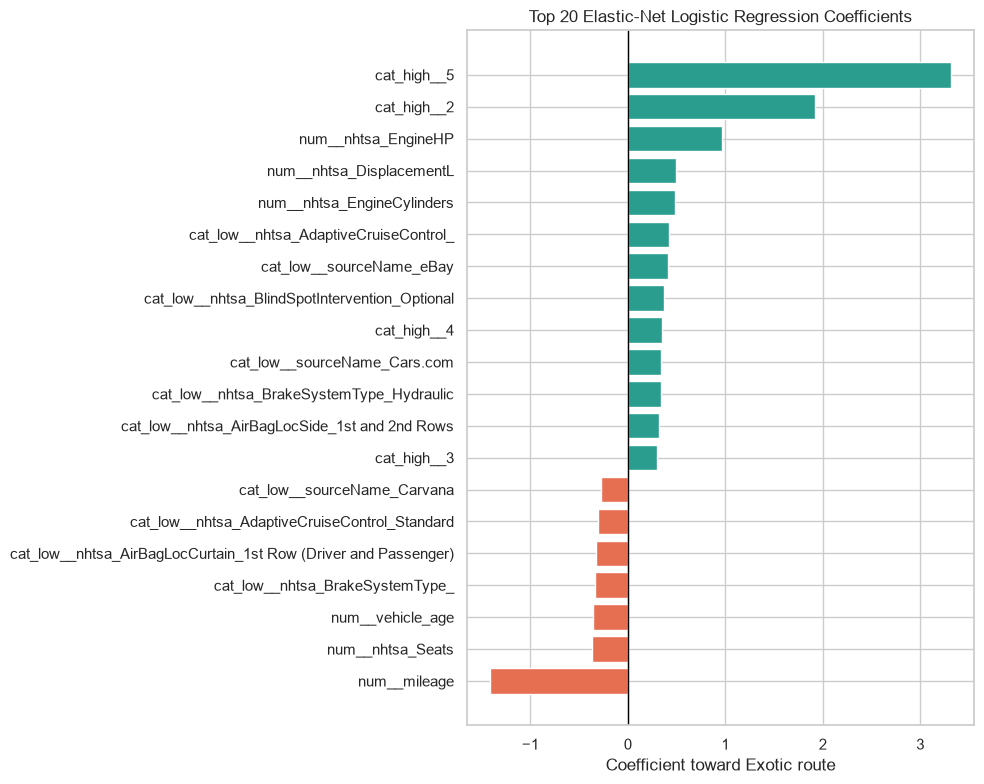

In [6]:
def get_feature_names(preprocessor, fallback_count=None):
    try:
        return preprocessor.get_feature_names_out()
    except Exception:
        if hasattr(preprocessor, "named_steps") and "features" in preprocessor.named_steps:
            try:
                return preprocessor.named_steps["features"].get_feature_names_out()
            except Exception:
                pass
        if fallback_count is None:
            return None
        return np.array([f"feature_{i}" for i in range(fallback_count)])


logistic_pipeline = classifier.named_estimators_["logistic"]
logistic_preprocessor = logistic_pipeline.named_steps["preprocessor"]
logistic_model = logistic_pipeline.named_steps["model"]

coefs = logistic_model.coef_.ravel()
feature_names = get_feature_names(logistic_preprocessor, fallback_count=len(coefs))
coef_df = (
    pd.DataFrame({"feature": feature_names, "coefficient": coefs})
    .assign(abs_coefficient=lambda df: df["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
    .head(20)
    .sort_values("coefficient")
)

plt.figure(figsize=(10, 8))
colors = np.where(coef_df["coefficient"] >= 0, "#2a9d8f", "#e76f51")
plt.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("Top 20 Elastic-Net Logistic Regression Coefficients")
plt.xlabel("Coefficient toward Exotic route")
plt.ylabel("")
plt.tight_layout()
plt.show()


## Step 3: Regressor Analysis

        Once the router chooses a lane, each regressor is solving a different pricing problem. Everyday prices are dense and lower variance; Exotic prices are sparse, capped, and outlier-prone. Evaluating them separately reveals whether each specialist behaves well inside its own domain.


### Predicted vs. Actual Prices

        These scatter plots compare each primary regressor against the true test rows for its natural price segment. The red dashed `y = x` line represents perfect prediction. Points above the line are underpredictions, and points below the line are overpredictions.


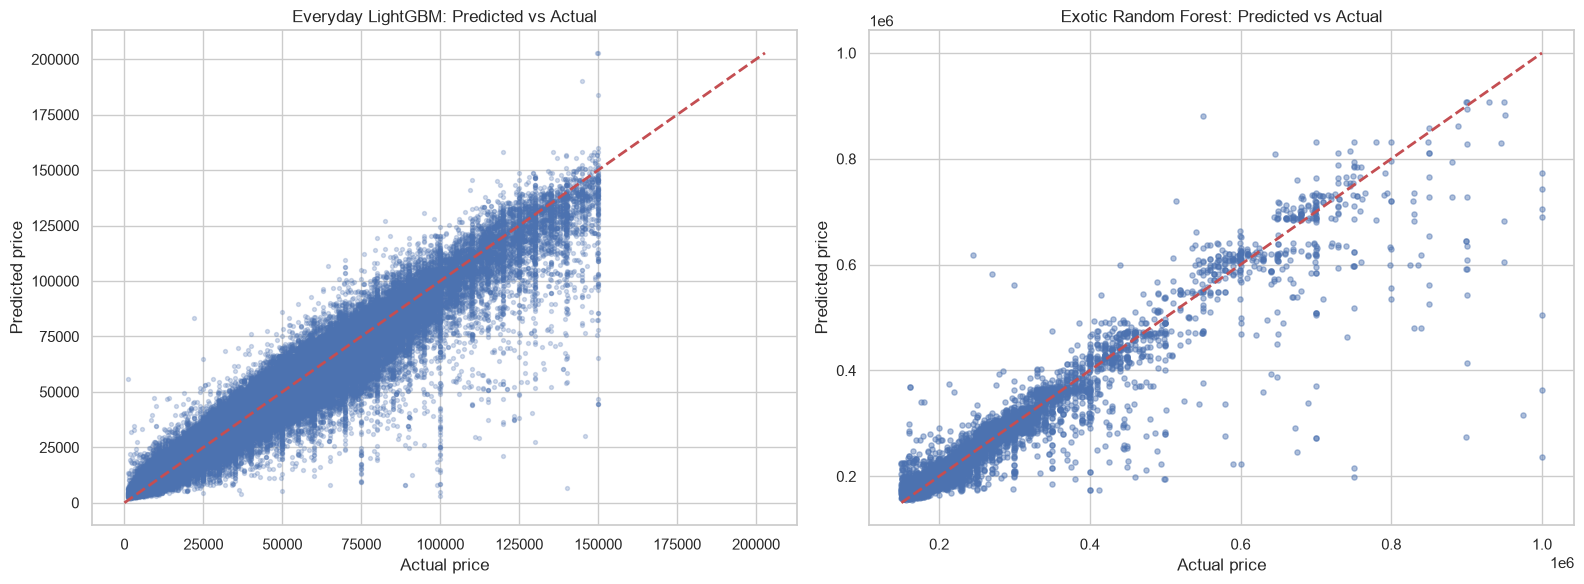

In [7]:
everyday_test_mask = y_test < HIGH_VALUE_THRESHOLD
exotic_test_mask = y_test >= HIGH_VALUE_THRESHOLD

X_test_everyday = X_test.loc[everyday_test_mask]
y_test_everyday = y_test.loc[everyday_test_mask]
X_test_exotic = X_test.loc[exotic_test_mask]
y_test_exotic = y_test.loc[exotic_test_mask]

y_pred_everyday = everyday_regressor.predict(X_test_everyday)
y_pred_exotic = exotic_regressor.predict(X_test_exotic)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_test_everyday, y_pred_everyday, alpha=0.25, s=8)
everyday_limit = max(y_test_everyday.max(), y_pred_everyday.max())
axes[0].plot([0, everyday_limit], [0, everyday_limit], "r--", linewidth=2)
axes[0].set_title("Everyday LightGBM: Predicted vs Actual")
axes[0].set_xlabel("Actual price")
axes[0].set_ylabel("Predicted price")

axes[1].scatter(y_test_exotic, y_pred_exotic, alpha=0.45, s=14)
exotic_limit = max(y_test_exotic.max(), y_pred_exotic.max())
axes[1].plot([HIGH_VALUE_THRESHOLD, exotic_limit], [HIGH_VALUE_THRESHOLD, exotic_limit], "r--", linewidth=2)
axes[1].set_title("Exotic Random Forest: Predicted vs Actual")
axes[1].set_xlabel("Actual price")
axes[1].set_ylabel("Predicted price")

plt.tight_layout()
plt.show()


### Residual Distributions

        Residuals are calculated as `Actual - Predicted`. A healthy regressor should have residuals centered near zero. Skew, long tails, or shifted centers reveal systematic overpricing or underpricing behavior that aggregate metrics can hide.


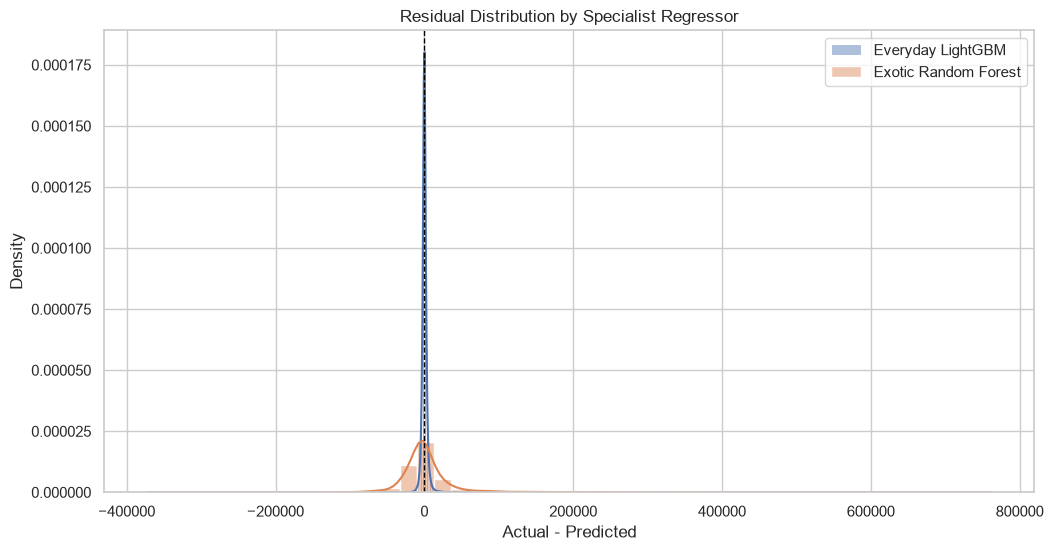

Everyday residual mean: $195.96
Exotic residual mean:   $3,440.10


In [8]:
everyday_residuals = y_test_everyday.to_numpy() - y_pred_everyday
exotic_residuals = y_test_exotic.to_numpy() - y_pred_exotic

plt.figure(figsize=(12, 6))
sns.histplot(everyday_residuals, kde=True, stat="density", bins=80, label="Everyday LightGBM", alpha=0.45)
sns.histplot(exotic_residuals, kde=True, stat="density", bins=50, label="Exotic Random Forest", alpha=0.45)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Residual Distribution by Specialist Regressor")
plt.xlabel("Actual - Predicted")
plt.ylabel("Density")
plt.legend()
plt.show()

print(f"Everyday residual mean: ${everyday_residuals.mean():,.2f}")
print(f"Exotic residual mean:   ${exotic_residuals.mean():,.2f}")


### SHAP Feature Importance

        SHAP values explain how features push the Everyday LightGBM model prediction up or down for individual rows. This is where non-linear signals such as `vehicle_age`, `Reliability_Index`, sentiment volatility, mileage, and technical vehicle attributes become visible. The model was trained through a log target transform, so the SHAP values explain movement in the transformed model output.


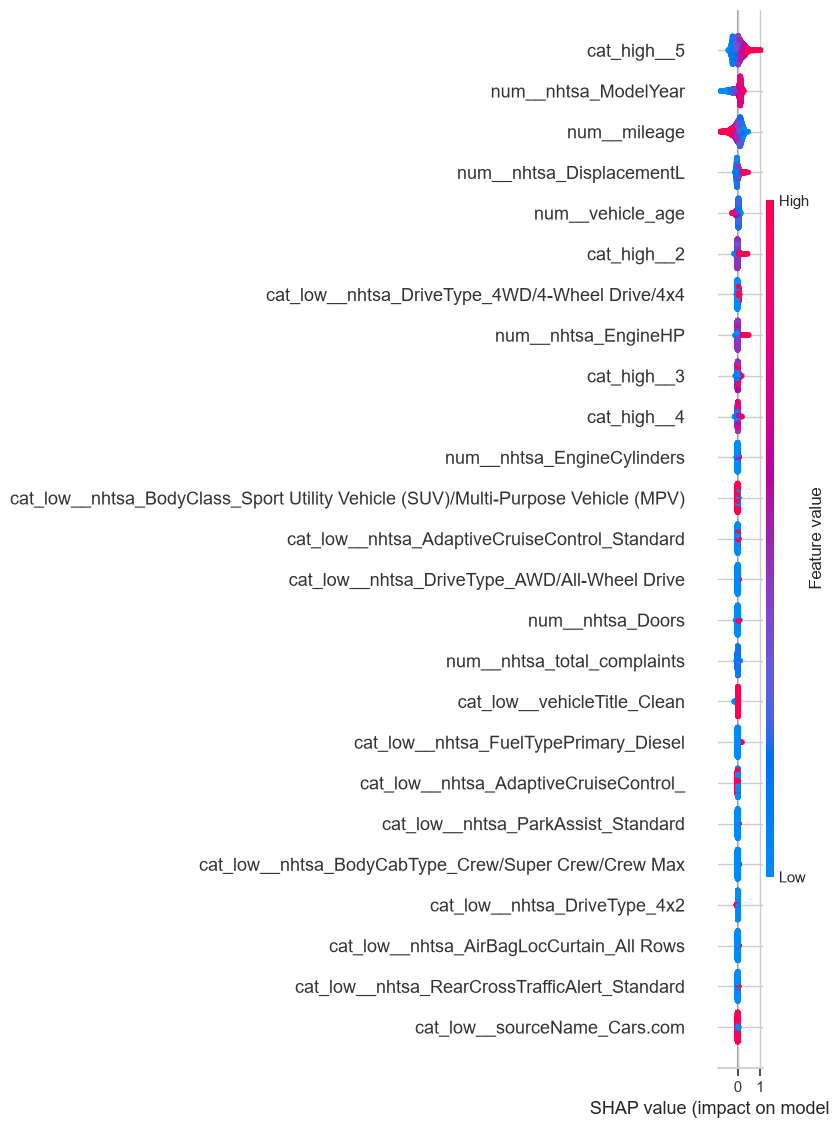

In [9]:
import shap

shap_sample_size = min(5_000, X_test_everyday.shape[0])
X_shap_raw = X_test_everyday.sample(shap_sample_size, random_state=42)

everyday_preprocessor = everyday_regressor.named_steps["preprocessor"]
everyday_ttr = everyday_regressor.named_steps["model"]
everyday_lgbm_model = everyday_ttr.regressor_

X_shap_encoded = everyday_preprocessor.transform(X_shap_raw)
shap_feature_names = get_feature_names(everyday_preprocessor, fallback_count=X_shap_encoded.shape[1])

if hasattr(X_shap_encoded, "toarray"):
    X_shap_for_plot = X_shap_encoded.toarray()
else:
    X_shap_for_plot = X_shap_encoded

explainer = shap.TreeExplainer(everyday_lgbm_model)
shap_values = explainer.shap_values(X_shap_for_plot)

shap.summary_plot(
    shap_values,
    X_shap_for_plot,
    feature_names=shap_feature_names,
    max_display=25,
    show=True,
)


## Step 4: Full Pipeline & Error Stratification

        The final production behavior is the routed system, not either regressor in isolation. This section recreates the routing logic, combines the predictions back into the original test order, and then reports error by price band so stakeholders can see exactly where the system is strongest and weakest.


In [10]:
def predict_routed_prices(X):
    predicted_labels = classifier.predict(X)
    routed_predictions = np.empty(X.shape[0], dtype=np.float64)

    everyday_mask = predicted_labels == 0
    exotic_mask = predicted_labels == 1

    if everyday_mask.any():
        routed_predictions[everyday_mask] = everyday_regressor.predict(X.loc[everyday_mask])
    if exotic_mask.any():
        routed_predictions[exotic_mask] = exotic_regressor.predict(X.loc[exotic_mask])

    return routed_predictions, predicted_labels


y_pred, routed_labels = predict_routed_prices(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Full Routed Pipeline Metrics")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAE:  ${mae:,.2f}")
print(f"MAPE: {mape * 100:.2f}%")
print(f"R2:   {r2:.4f}")
print()
print(f"Rows routed Everyday: {(routed_labels == 0).sum():,}")
print(f"Rows routed Exotic:   {(routed_labels == 1).sum():,}")


Full Routed Pipeline Metrics
RMSE: $8,477.46
MAE:  $2,749.37
MAPE: 9.06%
R2:   0.9220

Rows routed Everyday: 796,969
Rows routed Exotic:   9,682


### Error by Price Band

        Global MAE and MAPE average together very different business cases. Segmenting by actual price band shows whether the model is reliable for common inventory, premium inventory, and capped high-end vehicles. This is often the most useful chart for non-technical stakeholders because it maps model error to recognizable market tiers.


     $0-$30k | Rows:  491,336 | MAE: $  1,641.41 | MAPE:   9.69%
   $30k-$75k | Rows:  290,524 | MAE: $  3,298.59 | MAPE:   7.55%
  $75k-$150k | Rows:   18,774 | MAE: $ 16,645.12 | MAPE:  16.67%
 $150k-$300k | Rows:    4,191 | MAE: $ 14,647.82 | MAPE:   7.03%
      $300k+ | Rows:    1,826 | MAE: $ 43,314.78 | MAPE:   8.87%


,price_band,rows,MAE,MAPE,MAPE_percent
0,$0-$30k,491336,1641.413825,0.096875,9.687543
1,$30k-$75k,290524,3298.593940,0.075491,7.549122
2,$75k-$150k,18774,16645.123583,0.166708,16.670819
3,$150k-$300k,4191,14647.823662,0.070282,7.028179
4,$300k+,1826,43314.781612,0.088708,8.870845


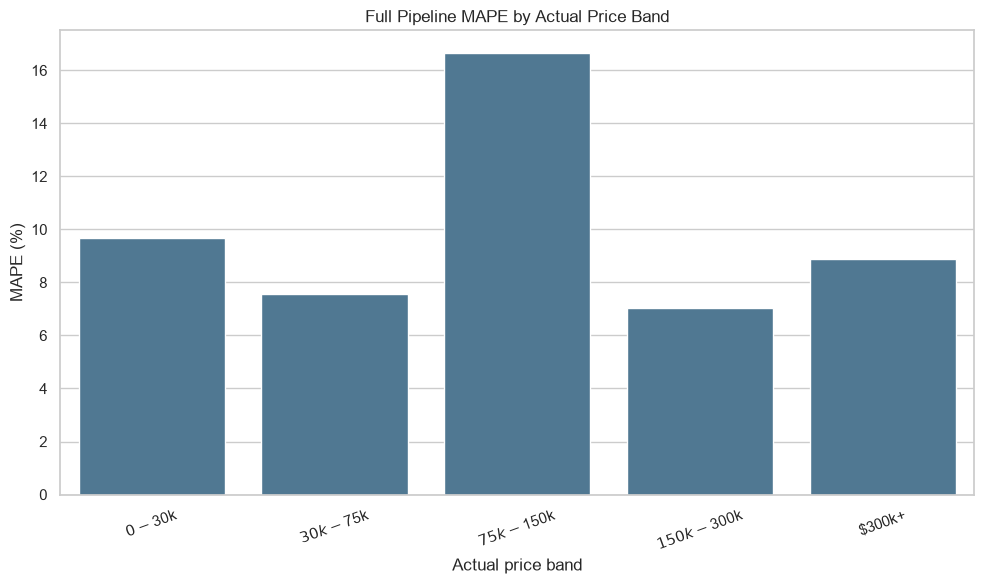

In [11]:
results_df = pd.DataFrame(
    {
        "actual": y_test.to_numpy(),
        "predicted": y_pred,
        "route": np.where(routed_labels == 1, "Exotic", "Everyday"),
    }
)
results_df["absolute_error"] = (results_df["actual"] - results_df["predicted"]).abs()
results_df["absolute_percentage_error"] = results_df["absolute_error"] / results_df["actual"].replace(0, np.nan)

bins = [0, 30_000, 75_000, 150_000, 300_000, np.inf]
labels = ["$0-$30k", "$30k-$75k", "$75k-$150k", "$150k-$300k", "$300k+"]
results_df["price_band"] = pd.cut(
    results_df["actual"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False,
)

band_rows = []
for label in labels:
    band_df = results_df[results_df["price_band"] == label]
    if band_df.empty:
        band_rows.append({"price_band": label, "rows": 0, "MAE": np.nan, "MAPE": np.nan})
        continue

    band_mae = mean_absolute_error(band_df["actual"], band_df["predicted"])
    band_mape = mean_absolute_percentage_error(band_df["actual"], band_df["predicted"])
    band_rows.append(
        {
            "price_band": label,
            "rows": len(band_df),
            "MAE": band_mae,
            "MAPE": band_mape,
        }
    )
    print(f"{label:>12} | Rows: {len(band_df):>8,} | MAE: ${band_mae:>10,.2f} | MAPE: {band_mape * 100:>6.2f}%")

band_metrics = pd.DataFrame(band_rows)
band_metrics["MAPE_percent"] = band_metrics["MAPE"] * 100
display(band_metrics)

plt.figure(figsize=(10, 6))
sns.barplot(data=band_metrics, x="price_band", y="MAPE_percent", color="#457b9d")
plt.title("Full Pipeline MAPE by Actual Price Band")
plt.xlabel("Actual price band")
plt.ylabel("MAPE (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
